In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from acm import NominalACM
import matplotlib.pyplot as plt
from build_moex_curve import build_moex_curve
from ruonia import load_ruonia_1m, build_ruonia_monthly
from run_acm_model import run_acm_model


In [2]:
def tenor_columns(df: pd.DataFrame) -> list[str]:
    return sorted(
        [c for c in df.columns if re.fullmatch(r"M\d{3}", c)],
        key=lambda c: int(c[1:]),
    )


def to_pyacm_curve(curve_df: pd.DataFrame) -> pd.DataFrame:
    df = curve_df.copy()
    df["date"] = pd.to_datetime(df["month_end"])
    df = df.set_index("date").sort_index()

    cols = tenor_columns(df)
    yield_curve = df[cols].copy()
    yield_curve.columns = [int(c[1:]) for c in cols]
    yield_curve = np.log1p(yield_curve / 100.0)

    yield_curve.index.name = "date"
    yield_curve.columns.name = "maturity_months"
    return yield_curve


def make_library_scores(acm: NominalACM) -> pd.DataFrame:
    scores = acm.pc_factors_m.reset_index().rename(
        columns={
            "date": "month_end",
            "PC 1": "PC1",
            "PC 2": "PC2",
            "PC 3": "PC3",
        }
    )
    scores["month_end"] = pd.to_datetime(scores["month_end"])
    scores["month"] = scores["month_end"].dt.to_period("M").astype(str)
    return scores[["month", "month_end", "PC1", "PC2", "PC3"]].copy()


def fit_short_rate_ruonia(scores_df: pd.DataFrame, ruonia_monthly: pd.DataFrame):
    merged = scores_df.merge(
        ruonia_monthly[["month", "month_end", "short_rate_monthly_cc"]],
        on=["month", "month_end"],
        how="inner",
    )
    if merged.empty:
        raise ValueError("No overlap between library factors and RUONIA monthly series")

    x = np.column_stack([np.ones(len(merged)), merged[["PC1", "PC2", "PC3"]].to_numpy(dtype=float)])
    y = merged["short_rate_monthly_cc"].to_numpy(dtype=float)
    coef, _, _, _ = np.linalg.lstsq(x, y, rcond=None)
    fitted = x @ coef
    residuals = y - fitted

    params = pd.DataFrame(
        {
            "parameter": ["delta0", "delta1_PC1", "delta1_PC2", "delta1_PC3", "sigma2"],
            "value": [float(coef[0]), float(coef[1]), float(coef[2]), float(coef[3]), float(np.var(residuals, ddof=0))],
        }
    )
    return float(coef[0]), coef[1:].astype(float), merged, params


def build_library_term_premium_frame(acm: NominalACM) -> pd.DataFrame:
    months = list(acm.curve.columns)
    arrays = {"date": acm.curve.index}
    for month in months:
        arrays[f"obs_M{month:03d}"] = acm.curve[month].to_numpy(dtype=float) * 100.0
        arrays[f"fit_M{month:03d}"] = acm.miy[month].to_numpy(dtype=float) * 100.0
        arrays[f"rn_M{month:03d}"] = acm.rny[month].to_numpy(dtype=float) * 100.0
        arrays[f"tp_M{month:03d}"] = acm.tp[month].to_numpy(dtype=float) * 100.0
    return pd.DataFrame(arrays)


def build_hybrid_term_premium(acm: NominalACM, delta0: float, delta1: np.ndarray) -> pd.DataFrame:
    months = list(acm.curve.columns)
    n = len(months)

    a_fit = np.zeros(n)
    b_fit = np.zeros((n, acm.n_factors))
    a_rn = np.zeros(n)
    b_rn = np.zeros((n, acm.n_factors))

    a_fit[0] = -delta0
    b_fit[0, :] = -delta1
    a_rn[0] = -delta0
    b_rn[0, :] = -delta1

    mu = np.asarray(acm.mu).reshape(-1, 1)
    phi = np.asarray(acm.phi)
    lambda0 = np.asarray(acm.lambda0).reshape(-1, 1)
    lambda1 = np.asarray(acm.lambda1)
    s0 = np.asarray(acm.s0).reshape(-1, 1)
    omega_scalar = float(acm.omega[0, 0])

    for idx in range(1, n):
        prev_fit = b_fit[idx - 1, :]
        prev_rn = b_rn[idx - 1, :]

        s0term_fit = 0.5 * (np.kron(prev_fit, prev_fit) @ s0 + omega_scalar)
        s0term_rn = 0.5 * (np.kron(prev_rn, prev_rn) @ s0 + omega_scalar)

        a_fit[idx] = float(a_fit[idx - 1] + prev_fit @ (mu - lambda0)[:, 0] + s0term_fit + a_fit[0])
        b_fit[idx, :] = prev_fit @ (phi - lambda1) + b_fit[0, :]

        a_rn[idx] = float(a_rn[idx - 1] + prev_rn @ mu[:, 0] + s0term_rn + a_rn[0])
        b_rn[idx, :] = prev_rn @ phi + b_rn[0, :]

    factors_d = acm.pc_factors_d.rename(
        columns={"PC 1": "PC1", "PC 2": "PC2", "PC 3": "PC3"}
    )[["PC1", "PC2", "PC3"]].to_numpy(dtype=float)

    arrays = {"date": acm.curve.index}
    for idx, month in enumerate(months):
        tau = month / 12.0
        fit = -((a_fit[idx] + factors_d @ b_fit[idx, :]) / tau)
        rn = -((a_rn[idx] + factors_d @ b_rn[idx, :]) / tau)
        obs = acm.curve[month].to_numpy(dtype=float)

        arrays[f"obs_M{month:03d}"] = obs * 100.0
        arrays[f"fit_M{month:03d}"] = fit * 100.0
        arrays[f"rn_M{month:03d}"] = rn * 100.0
        arrays[f"tp_M{month:03d}"] = (fit - rn) * 100.0

    return pd.DataFrame(arrays)


In [3]:
CLEAN_DIR = Path('.')
DEFAULT_DYNAMIC_PATH = CLEAN_DIR / 'data' / 'dynamic.csv'
DEFAULT_DAILY_OUTPUT = CLEAN_DIR / 'output' / 'moex_curve_daily.csv'
DEFAULT_MONTHLY_OUTPUT = CLEAN_DIR / 'output' / 'moex_curve_monthly.csv'
RUONIA_1M_PATH = CLEAN_DIR / 'data' / 'ruonia_1M.csv'

months = list(range(1, 181))

_, all_monthly_curve = build_moex_curve(
    dynamic_path=DEFAULT_DYNAMIC_PATH,
    daily_output_path=DEFAULT_DAILY_OUTPUT,
    monthly_output_path=DEFAULT_MONTHLY_OUTPUT,
    months=months,
)
START_DATE = "2014-01-31"
END_DATE = "2024-05-31"

start_date = pd.to_datetime(START_DATE)
end_date = pd.to_datetime(END_DATE)

all_monthly_curve["month_end"] = pd.to_datetime(all_monthly_curve["month_end"])

all_monthly_curve = (
    all_monthly_curve.loc[
        all_monthly_curve["month_end"].between(start_date, end_date, inclusive="both")
    ]
    .sort_values("month_end")
    .reset_index(drop=True)
)

all_monthly_curve["month"] = all_monthly_curve["month_end"].dt.to_period("M").astype(str)
all_monthly_curve.head()

ruonia_monthly = build_ruonia_monthly(load_ruonia_1m(RUONIA_1M_PATH))
yield_curve = to_pyacm_curve(all_monthly_curve)


In [4]:
SENS_TENOR = 120

sensitivity_configs = {
    "full": {
        "selected_maturities": [6, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120],
        "date_from": "2014-01-31",
        "date_to": "2026-03-10",
        "short_rate_proxy": "ruonia_1m",
        "n_factors": 5,
    },
    "cb-like": {
        "selected_maturities": [6, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120],
        "date_from": "2015-01-31",
        "date_to": "2024-05-31",
        "short_rate_proxy": "ruonia_1m",
        "n_factors": 3,
    },
    "cb-not_ruonia": {
        "selected_maturities": [6, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120],
        "date_from": "2015-01-31",
        "date_to": "2024-05-31",
        # "short_rate_proxy": "ruonia_1m",
        "n_factors": 3,
    },
    # "base_ruonia": {
    #     "selected_maturities": [12, 24, 60, 120],
    #     "date_from": "2018-01-31",
    #     "date_to": "2024-12-31",
    #     "short_rate_proxy": "ruonia_1m",
    #     "n_factors": 3,
    # },
    # "curve1m_proxy": {
    #     "selected_maturities": [12, 24, 60, 120],
    #     "date_from": "2018-01-31",
    #     "date_to": "2024-12-31",
    #     "short_rate_proxy": "curve_1m",
    #     "n_factors": 3,
    # },
    # "short_sample": {
    #     "selected_maturities": [12, 24, 60, 120],
    #     "date_from": "2020-01-31",
    #     "date_to": "2024-12-31",
    #     "short_rate_proxy": "ruonia_1m",
    #     "n_factors": 3,
    # },
    # "longer_sample": {
    #     "selected_maturities": [12, 24, 60, 120],
    #     "date_from": "2016-01-31",
    #     "date_to": "2024-12-31",
    #     "short_rate_proxy": "ruonia_1m",
    #     "n_factors": 3,
    # },
    # "broader_maturities": {
    #     "selected_maturities": [12, 24, 36, 60, 84, 120, 180],
    #     "date_from": "2018-01-31",
    #     "date_to": "2024-12-31",
    #     "short_rate_proxy": "ruonia_1m",
    #     "n_factors": 3,
    # },
}

sensitivity_runs = {
    name: run_acm_model(**config)
    for name, config in sensitivity_configs.items()
}

tp_compare = pd.concat(
    [
        run.term_premium_frame[["date", f"tp_M{SENS_TENOR:03d}"]]
        .rename(columns={f"tp_M{SENS_TENOR:03d}": name})
        .set_index("date")
        for name, run in sensitivity_runs.items()
    ],
    axis=1,
).sort_index()


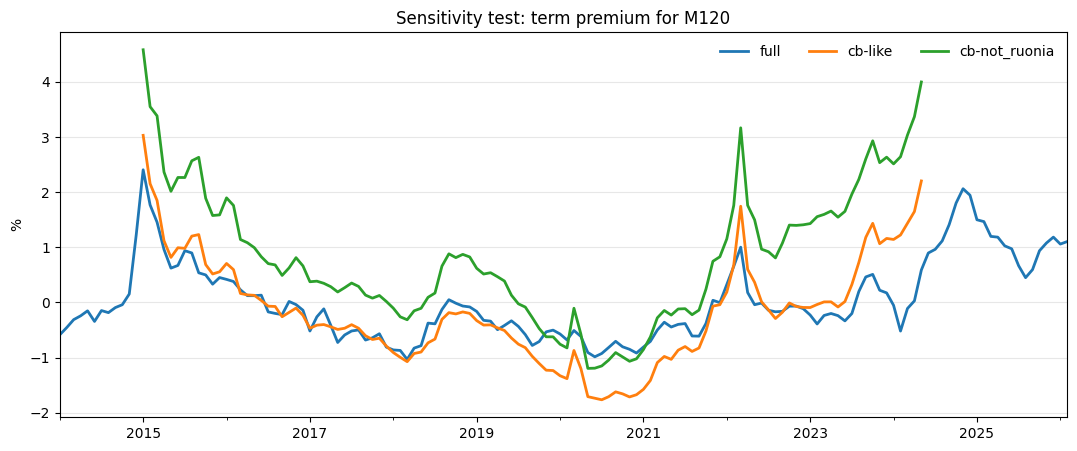

In [5]:
ax = tp_compare.plot(figsize=(13, 5), lw=2)

ax.set_title(f"Sensitivity test: term premium for M{SENS_TENOR:03d}")
ax.set_ylabel("%")
ax.set_xlabel("")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(frameon=False, ncol=3)
plt.show()


In [ ]:
SENS_TENOR = 120

sensitivity_configs = {
    "cb-[6, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120]": {
        "selected_maturities": [6, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120],
        "date_from": "2015-01-31",
        "date_to": "2024-05-31",
        "short_rate_proxy": "ruonia_1m",
        "n_factors": 5,
    },
    "cb-hypothisis": {
    "selected_maturities": tuple(range(12, 181, 12)),
    "date_from": "2015-01-31",
    "date_to": "2024-05-31",
    "short_rate_proxy": "ruonia_1m",
    "n_factors": 3,
    },
    "cb-tuple(range(6, 181, 6))": {
        "selected_maturities": tuple(range(6, 181, 6)),
        "date_from": "2015-01-31",
        "date_to": "2024-05-31",
        "short_rate_proxy": "ruonia_1m",
        "n_factors": 5,
    },
    "cb-tuple(range(1, 181, 1))": {
        "selected_maturities": tuple(range(1, 181, 1)),
        "date_from": "2015-01-31",
        "date_to": "2024-05-31",
        "short_rate_proxy": "ruonia_1m",
        "n_factors": 5,
    },
     "cb-tuple(range(1, 121, 1))": {
        "selected_maturities": tuple(range(1, 121, 1)),
        "date_from": "2015-01-31",
        "date_to": "2024-05-31",
        "short_rate_proxy": "ruonia_1m",
        "n_factors": 5,
    },
     "cb-tuple(range(1, 181, 12))": {
        "selected_maturities": tuple(range(1, 181, 12)),
        "date_from": "2015-01-31",
        "date_to": "2024-05-31",
        "short_rate_proxy": "ruonia_1m",
        "n_factors": 5,
    },
    "cb-tuple(range(1, 121, 12))": {
        "selected_maturities": tuple(range(1, 121, 12)),
        "date_from": "2015-01-31",
        "date_to": "2024-05-31",
        "short_rate_proxy": "ruonia_1m",
        "n_factors": 5,
    },
}

sensitivity_runs = {
    name: run_acm_model(**config)
    for name, config in sensitivity_configs.items()
}

tp_compare = pd.concat(
    [
        run.term_premium_frame[["date", f"tp_M{SENS_TENOR:03d}"]]
        .rename(columns={f"tp_M{SENS_TENOR:03d}": name})
        .set_index("date")
        for name, run in sensitivity_runs.items()
    ],
    axis=1,
).sort_index()


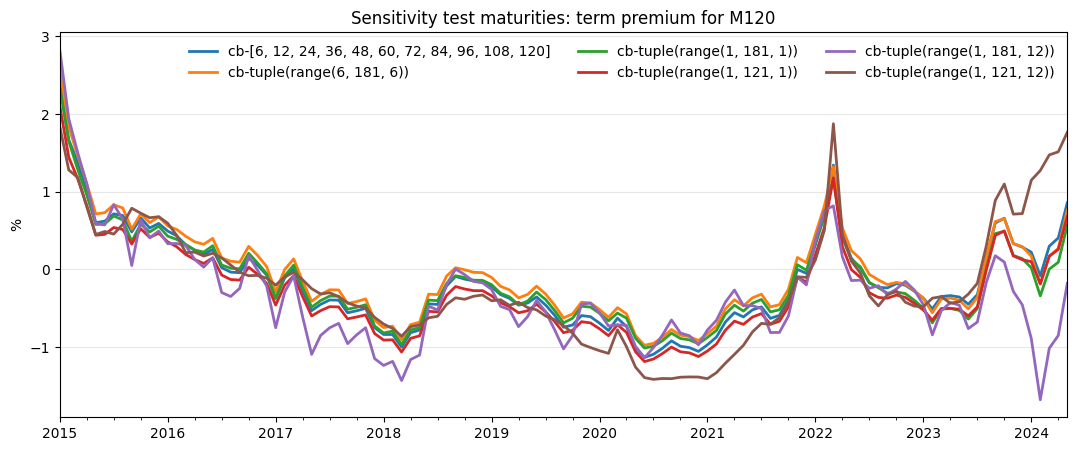

In [ ]:
ax = tp_compare.plot(figsize=(13, 5), lw=2)

ax.set_title(f"Sensitivity test maturities: term premium for M{SENS_TENOR:03d}")
ax.set_ylabel("%")
ax.set_xlabel("")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(frameon=False, ncol=3)
plt.show()
